# loading data

In [111]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import geopandas as gpd
import re
import matplotlib.ticker as ticker
from matplotlib.patheffects import withStroke
import plotly.express as px

In [76]:
df1 = pd.read_csv('final_clean.csv')

In [77]:
df2 = pd.read_csv('appendix.csv')

In [78]:
df1.columns

Index(['Province', 'type', 'Year', 'Schools', 'Classes', 'TeachStaff_Total',
       'TeachStaff_Female', 'NonTeachStaff_Total', 'NonTeachStaff_Female',
       'Grade_1_Enrollment_Total', 'Grade_1_Enrollment_Girl',
       'Grade_1_Repeaters_Total', 'Grade_1_Repeaters_Girl',
       'Grade_2_Enrollment_Total', 'Grade_2_Enrollment_Girl',
       'Grade_2_Repeaters_Total', 'Grade_2_Repeaters_Girl',
       'Grade_3_Enrollment_Total', 'Grade_3_Enrollment_Girl',
       'Grade_3_Repeaters_Total', 'Grade_3_Repeaters_Girl',
       'Grade_4_Enrollment_Total', 'Grade_4_Enrollment_Girl',
       'Grade_4_Repeaters_Total', 'Grade_4_Repeaters_Girl',
       'Grade_5_Enrollment_Total', 'Grade_5_Enrollment_Girl',
       'Grade_5_Repeaters_Total', 'Grade_5_Repeaters_Girl',
       'Grade_6_Enrollment_Total', 'Grade_6_Enrollment_Girl',
       'Grade_6_Repeaters_Total', 'Grade_6_Repeaters_Girl',
       'Grade_7_Enrollment_Total', 'Grade_7_Enrollment_Girl',
       'Grade_7_Repeaters_Total', 'Grade_7_Repeaters_G

# group barchart

In [79]:
total_schools = df1.groupby(['Year','type'])['Schools'].sum().reset_index()
total_classes = df1.groupby(['Year','type'])['Classes'].sum().reset_index()
total_enrollment = df1.groupby(['Year','type'])['Total_Enrollment_Total'].sum().reset_index()
total_enrollment_girl = df1.groupby(['Year','type'])['Total_Enrollment_Girl'].sum().reset_index()
total_staff = df1.groupby(['Year','type'])['TeachStaff_Total'].sum().reset_index()
total_staff_girl = df1.groupby(['Year','type'])['TeachStaff_Female'].sum().reset_index()
non_teach_staff_total = df1.groupby(['Year','type'])['NonTeachStaff_Total'].sum().reset_index()

In [80]:
sns.set_style('whitegrid')

In [81]:
fig = make_subplots(rows=1, cols=1, subplot_titles=("School Growth Progress",))
fig.add_trace(go.Bar(
    x=total_schools[total_schools['type'] == 'private']['Year'],
    y=total_schools[total_schools['type'] == 'private']['Schools'],
    name="Private",
    marker_color='blue',
    hovertemplate="Count: %{y}<extra></extra>"
))
fig.add_trace(go.Bar(
    x=total_schools[total_schools['type'] == 'public']['Year'],
    y=total_schools[total_schools['type'] == 'public']['Schools'],
    name="Public",
    marker_color='orange',
    hovertemplate="Count: %{y}<extra></extra>"
))
for s_type, color in zip(['private', 'public'], ['darkblue', 'darkorange']):
    df_sub = total_schools[total_schools['type'] == s_type]
    fig.add_trace(go.Scatter(
        x=df_sub['Year'], 
        y=df_sub['Schools'],
        name=f"{s_type} Trend",
        mode='lines+markers',
        line=dict(color=color, width=2),
        hoverinfo='skip'
    ))
fig.update_layout(
    barmode='group',
    height=500, 
    width=900,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.05
    ),
    hovermode="x unified" 
)
fig.show()

In [82]:
fig = make_subplots(rows=1, cols=1, subplot_titles=("Class Growth Progress",))
fig.add_trace(go.Bar(
    x=total_classes[total_classes['type'] == 'private']['Year'],
    y=total_classes[total_classes['type'] == 'private']['Classes'],
    name="Private",
    marker_color='blue',
    hovertemplate="Count: %{y}<extra></extra>"
))
fig.add_trace(go.Bar(
    x=total_classes[total_classes['type'] == 'public']['Year'],
    y=total_classes[total_classes['type'] == 'public']['Classes'],
    name="Public",
    marker_color='orange',
    hovertemplate="Count: %{y}<extra></extra>"
))
for s_type, color in zip(['private', 'public'], ['darkblue', 'darkorange']):
    df_sub = total_classes[total_classes['type'] == s_type]
    fig.add_trace(go.Scatter(
        x=df_sub['Year'], 
        y=df_sub['Classes'],
        name=f"{s_type} Trend",
        mode='lines+markers',
        line=dict(color=color, width=2),
        hoverinfo='skip'
    ))
fig.update_layout(
    barmode='group',
    height=500, 
    width=900,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.05
    ),
    hovermode="x unified" 
)
fig.show()

In [83]:
pub_total  = total_enrollment[total_enrollment['type'] == 'public'].set_index('Year')['Total_Enrollment_Total']
priv_total = total_enrollment[total_enrollment['type'] == 'private'].set_index('Year')['Total_Enrollment_Total']
pub_girls  = total_enrollment_girl[total_enrollment_girl['type'] == 'public'].set_index('Year')['Total_Enrollment_Girl']
priv_girls = total_enrollment_girl[total_enrollment_girl['type'] == 'private'].set_index('Year')['Total_Enrollment_Girl']

pub_rest  = pub_total  - pub_girls   # total - girls
priv_rest = priv_total - priv_girls  # total - girls

years = total_enrollment['Year'].unique()
years.sort()

In [84]:
fig = make_subplots(
    rows=1, cols=len(years),
    subplot_titles=[str(y) for y in years],
    shared_yaxes=True,
    horizontal_spacing=0.02
)

for i, year in enumerate(years, start=1):
    show_legend = (i == 1)

    priv_g = priv_girls[year]
    priv_r = priv_rest[year]

    fig.add_trace(go.Bar(
        x=['Private'],
        y=[priv_g],
        name='Private (Girls)',
        marker_color='red',
        legendgroup='priv_girls',
        showlegend=show_legend,
        hovertemplate="Girls: %{customdata[0]:,}<extra></extra>",
        customdata=[[priv_g, priv_g + priv_r]]
    ), row=1, col=i)

    fig.add_trace(go.Bar(
        x=['Private'],
        y=[priv_r],
        name='Private (Total)',
        marker_color='blue',
        legendgroup='priv_rest',
        showlegend=show_legend,
        hovertemplate="Total: %{customdata[1]:,}<extra></extra>",
        customdata=[[priv_g, priv_g + priv_r]]
    ), row=1, col=i)

    pub_g = pub_girls[year]
    pub_r = pub_rest[year]
    fig.add_trace(go.Bar(
        x=['Public'],
        y=[pub_g],
        name='Public (Girls)',
        marker_color='green',
        legendgroup='pub_girls',
        showlegend=show_legend,
        hovertemplate="Girls: %{customdata[0]:,}<extra></extra>",
        customdata=[[pub_g, pub_g + pub_r]]
    ), row=1, col=i)

    fig.add_trace(go.Bar(
        x=['Public'],
        y=[pub_r],
        name='Public (Total)',
        marker_color='orange',
        legendgroup='pub_rest',
        showlegend=show_legend,
        hovertemplate="Total: %{customdata[1]:,}<extra></extra>",
        customdata=[[pub_g, pub_g + pub_r]]
    ), row=1, col=i)

fig.update_layout(
    barmode='stack',
    height=500,
    width=1000,
    title_text='Enrollment by Year',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    hovermode="x unified"
)

fig.show()

In [85]:
staff_pub_total  = total_staff[total_staff['type'] == 'public'].set_index('Year')['TeachStaff_Total']
staff_priv_total = total_staff[total_staff['type'] == 'private'].set_index('Year')['TeachStaff_Total']
staff_pub_girls  = total_staff_girl[total_staff_girl['type'] == 'public'].set_index('Year')['TeachStaff_Female']
staff_priv_girls = total_staff_girl[total_staff_girl['type'] == 'private'].set_index('Year')['TeachStaff_Female']

staff_pub_rest  = staff_pub_total  - staff_pub_girls   # total - girls
staff_priv_rest = staff_priv_total - staff_priv_girls  # total - girls

years = total_staff['Year'].unique()
years.sort()

In [86]:
fig = make_subplots(
    rows=1, cols=len(years),
    subplot_titles=[str(y) for y in years],
    shared_yaxes=True,
    horizontal_spacing=0.02
)

for i, year in enumerate(years, start=1):
    show_legend = (i == 1)

    priv_g = staff_priv_girls[year]
    priv_r = staff_priv_rest[year]

    fig.add_trace(go.Bar(
        x=['Private'],
        y=[priv_g],
        name='Private (Girls)',
        marker_color='red',
        legendgroup='priv_girls',
        showlegend=show_legend,
        hovertemplate="Girls: %{customdata[0]:,}<extra></extra>",
        customdata=[[priv_g, priv_g + priv_r]]
    ), row=1, col=i)

    fig.add_trace(go.Bar(
        x=['Private'],
        y=[priv_r],
        name='Private (Total)',
        marker_color='blue',
        legendgroup='priv_rest',
        showlegend=show_legend,
        hovertemplate="Total: %{customdata[1]:,}<extra></extra>",
        customdata=[[priv_g, priv_g + priv_r]]
    ), row=1, col=i)

    pub_g = staff_pub_girls[year]
    pub_r = staff_pub_rest[year]
    fig.add_trace(go.Bar(
        x=['Public'],
        y=[pub_g],
        name='Public (Girls)',
        marker_color='green',
        legendgroup='pub_girls',
        showlegend=show_legend,
        hovertemplate="Girls: %{customdata[0]:,}<extra></extra>",
        customdata=[[pub_g, pub_g + pub_r]]
    ), row=1, col=i)

    fig.add_trace(go.Bar(
        x=['Public'],
        y=[pub_r],
        name='Public (Total)',
        marker_color='orange',
        legendgroup='pub_rest',
        showlegend=show_legend,
        hovertemplate="Total: %{customdata[1]:,}<extra></extra>",
        customdata=[[pub_g, pub_g + pub_r]]
    ), row=1, col=i)

fig.update_layout(
    barmode='stack',
    height=500,
    width=1000,
    title_text='Teaching Staff by Year',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    hovermode="x unified"
)

fig.show()

# 

# cartogram

In [87]:
country_shapefile = gpd.read_file('map/khm_admbnda_adm1_gov.shx')

In [88]:
country_shapefile = country_shapefile.replace({'Oddar Meanchey': 'Otdar Meanchey',
                                               'Tboung Khmum': 'Tbaung Khmum'
                                               })

In [89]:
filtered_df = df1[
    (df1['Year'] == 2020) & 
    (df1['type'].isin(['private', 'public']))
]
total_schools_2020 = filtered_df.groupby(['Province'])['Schools'].sum().reset_index()

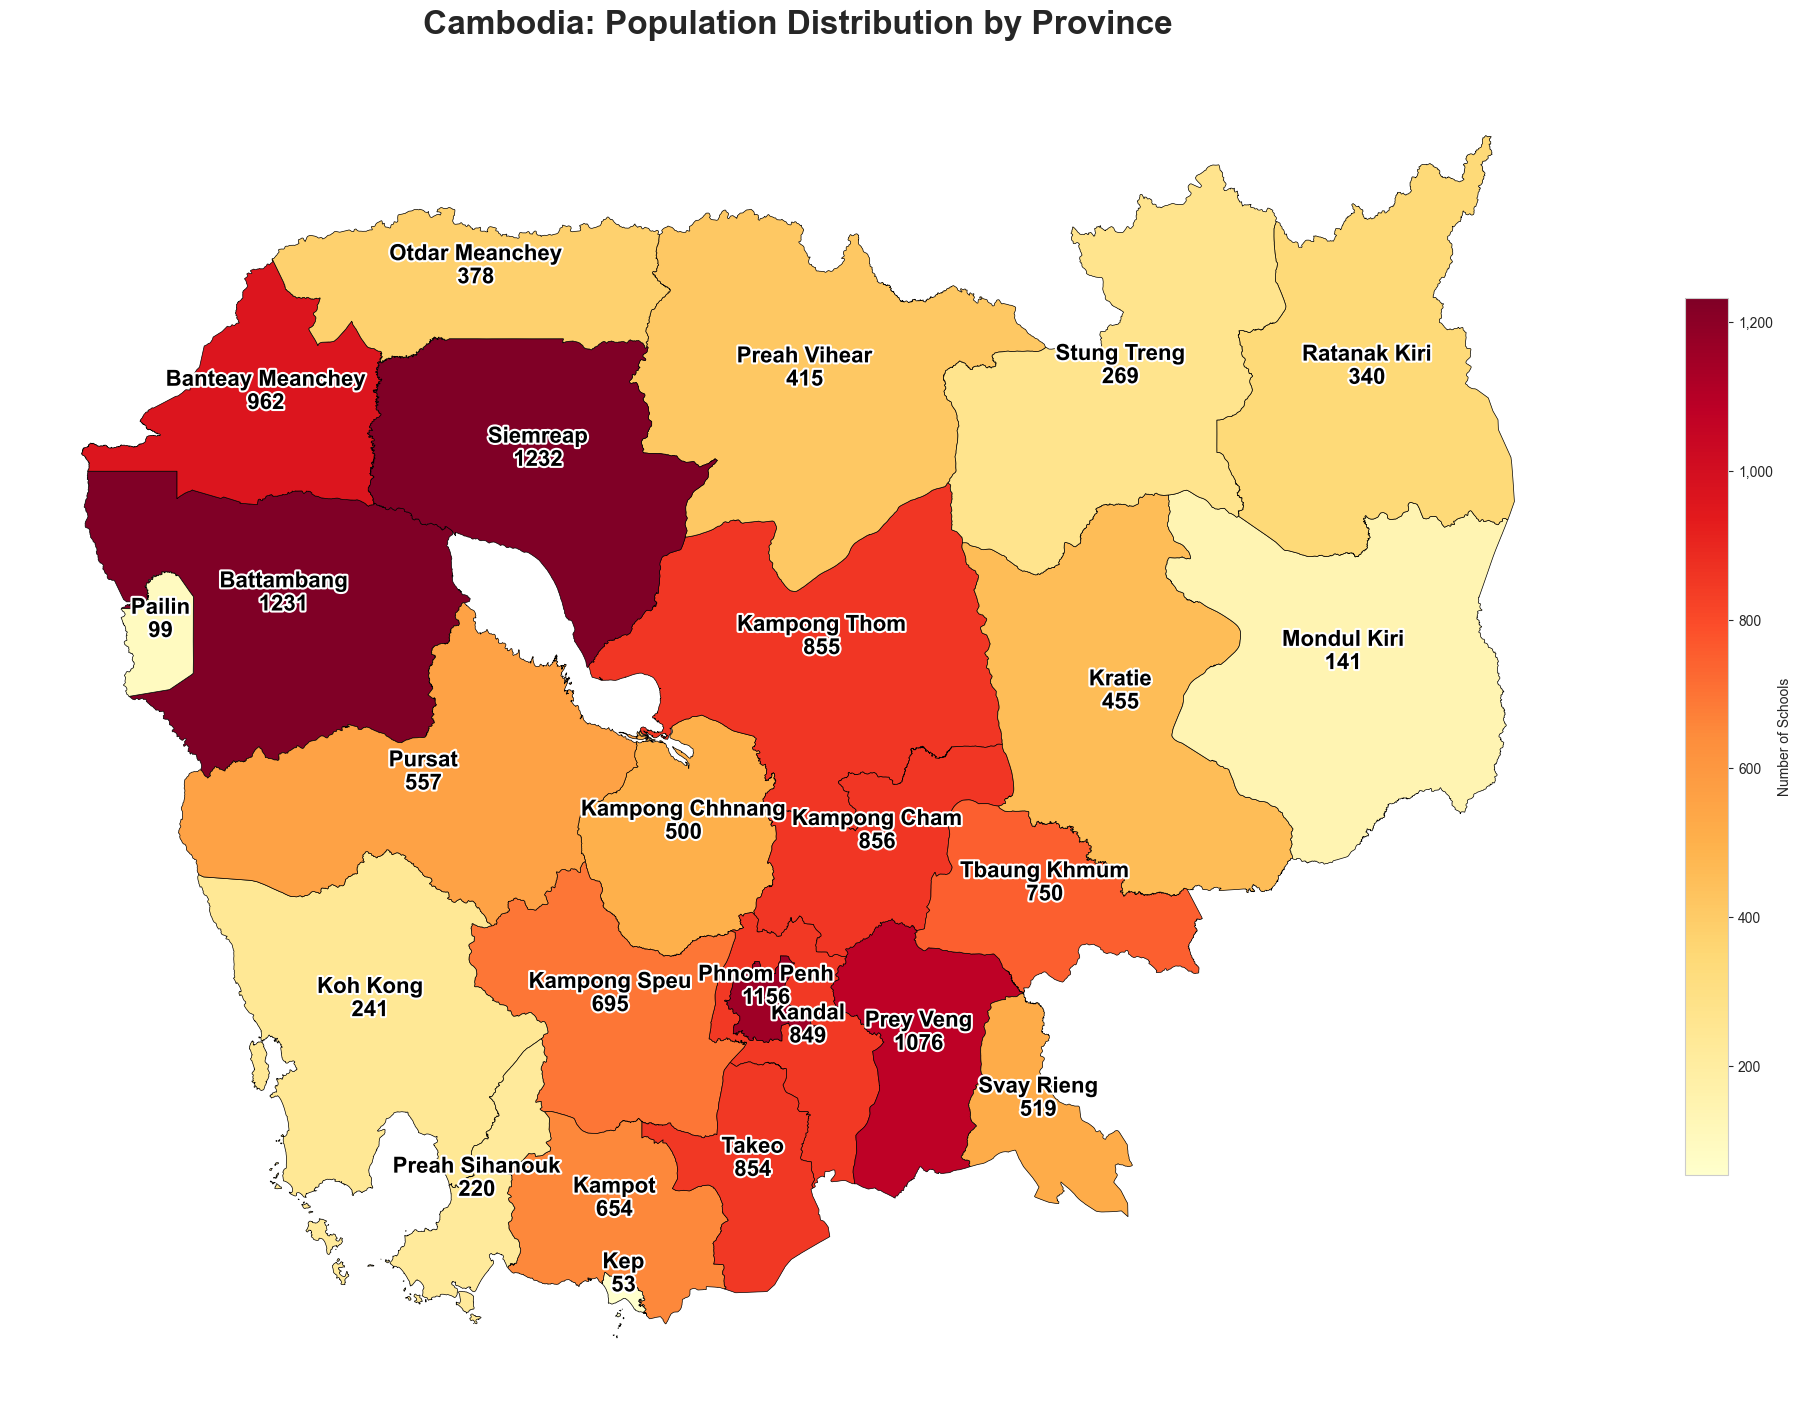

In [90]:
# 1. Setup the figure size for a high-res look
fig, ax = plt.subplots(1, 1, figsize=(20, 15))
merged = country_shapefile.merge(total_schools_2020, left_on='HRName', right_on='Province')
# 2. Plot the map with a clearer color bar 
# We use 'YlOrRd' for better visibility of province names
plot = merged.plot(column='Schools', 
                   ax=ax, 
                   legend=True, 
                   cmap='YlOrRd', 
                   edgecolor='black', 
                   linewidth=0.5,
                   legend_kwds={
                       'label': "Number of Schools",
                       'orientation': "vertical",
                       'shrink': 0.6,
                       'format': ticker.FuncFormatter(lambda x, p: format(int(x), ','))
                   })

# 3. Add Province Names and School Values at the center of each shape
for idx, row in merged.iterrows():
    if pd.notnull(row['Province']):
        centroid = row['geometry'].centroid
        # Format the text to show both province name and schools value
        text_label = f"{row['Province']}\n{row['Schools']:.0f}"
        
        ax.annotate(text=text_label, 
                    xy=(centroid.x, centroid.y),
                    horizontalalignment='center', 
                    fontsize=16, 
                    fontweight='bold',
                    color='black',
                    # This adds the white 'glow' so text is readable over dark colors
                    path_effects=[withStroke(linewidth=3, foreground="white")])

# 4. Final Styling
ax.set_title('Cambodia: Population Distribution by Province', fontsize=24, pad=30, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.show()

In [91]:
df_comparison = df1[df1['Year'].isin([2018, 2020])]
growth_df = df_comparison.groupby(['Province', 'type', 'Year'])['Schools'].sum().unstack()
growth_df['Growth'] = growth_df[2020].fillna(0) - growth_df[2018].fillna(0)
growth_df = growth_df.reset_index()

In [92]:
growth_df=growth_df.groupby('Province')['Growth'].sum().reset_index()

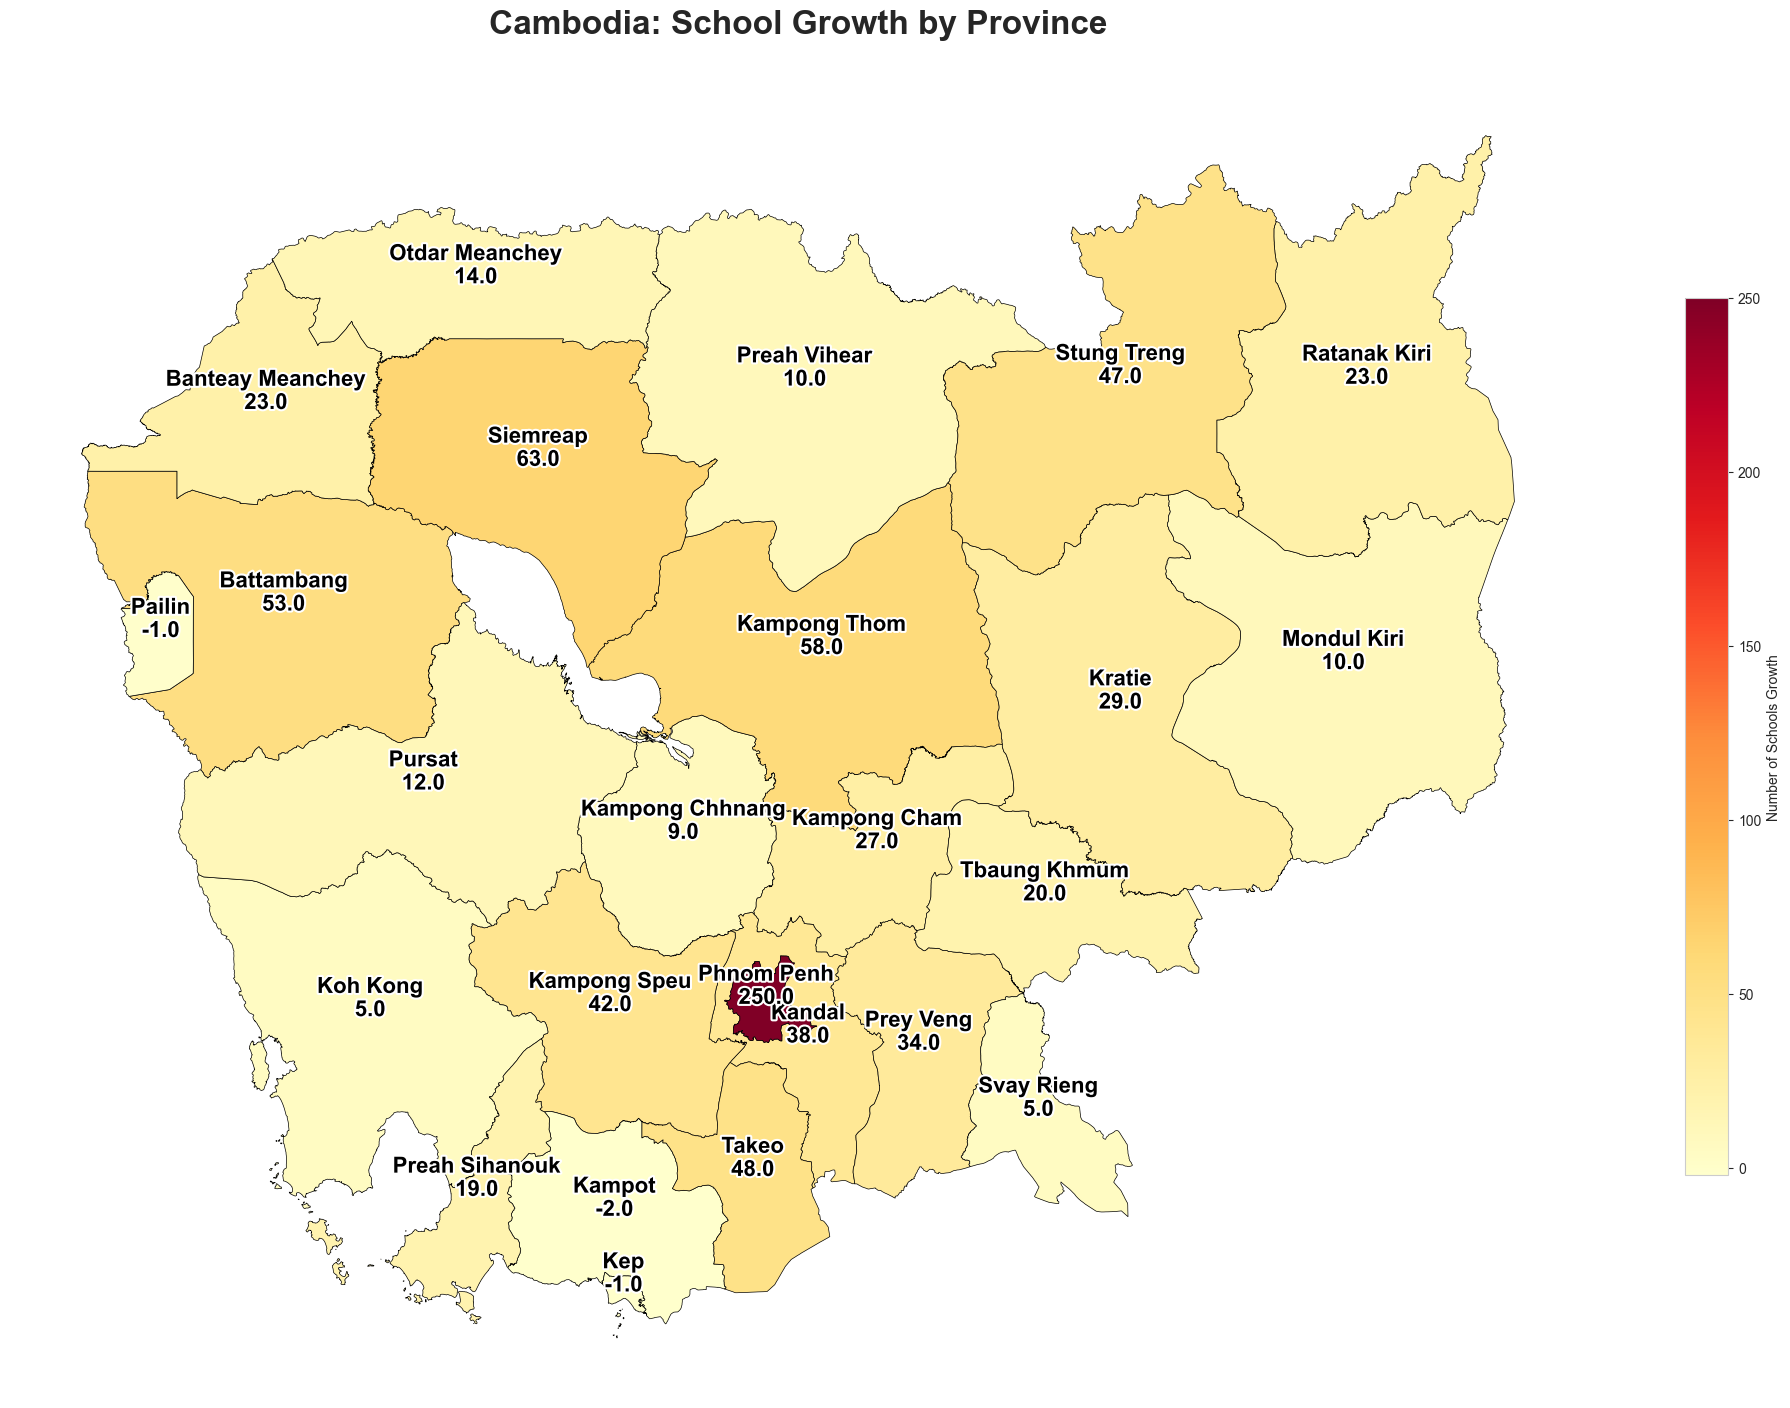

In [93]:
import matplotlib.ticker as ticker
from matplotlib.patheffects import withStroke

# 1. Setup the figure size for a high-res look
fig, ax = plt.subplots(1, 1, figsize=(20, 15))
merged = country_shapefile.merge(growth_df, left_on='HRName', right_on='Province')

# 2. Plot the map with a clearer color bar
plot = merged.plot(column='Growth', 
                   ax=ax, 
                   legend=True, 
                   cmap='YlOrRd', 
                   edgecolor='black', 
                   linewidth=0.5,
                   legend_kwds={
                       'label': "Number of Schools Growth",
                       'orientation': "vertical",
                       'shrink': 0.6,
                       'format': ticker.FuncFormatter(lambda x, p: format(int(x), ','))
                   })

# 3. Add Province Names and Growth Values at the center of each shape
for idx, row in merged.iterrows():
    if pd.notnull(row['Province']):
        centroid = row['geometry'].centroid
        # Format the text to show both province name and growth value
        text_label = f"{row['Province']}\n{row['Growth']:.1f}"
        
        ax.annotate(text=text_label, 
                    xy=(centroid.x, centroid.y),
                    horizontalalignment='center', 
                    fontsize=16, 
                    fontweight='bold',
                    color='black',
                    # This adds the white 'glow' so text is readable over dark colors
                    path_effects=[withStroke(linewidth=3, foreground="white")])

# 4. Final Styling
ax.set_title('Cambodia: School Growth by Province', fontsize=24, pad=30, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.show()

# stacked group bar chart

In [94]:
staff_lv = df1[[c for c in df1.columns if re.match(r'T_', c) or re.match(r'Year', c) or re.match(r'type', c)]]

In [95]:
staff_lv = staff_lv.groupby(['Year','type']).agg({'T_Primary': 'sum', 'T_LSec': 'sum', 'T_USec': 'sum','T_Graduate': 'sum','T_Graduate':'sum','T_PhD': 'sum'}).reset_index()

In [96]:
staff_lv

,Year,type,T_Primary,T_LSec,T_USec,T_Graduate,T_PhD
0,2018,private,186,815,3941,7877,15
1,2018,public,1651,17217,50808,22657,10
2,2019,private,262,788,4332,9875,23
3,2019,public,2482,17342,46437,25206,23
4,2020,private,582,892,4169,8568,93
5,2020,public,2796,15594,43435,30568,38


In [97]:
# Assuming your df is called 'df'
years = sorted(staff_lv['Year'].unique())

fig = make_subplots(
    rows=1, cols=len(years),
    subplot_titles=[str(y) for y in years],
    shared_yaxes=True,
    horizontal_spacing=0.02
)

# Color palette for education levels
colors = ["#FF0000", "#F14FF7", "#2724DF", '#45B7AA', "#00FF55"]

education_levels = ['T_Primary', 'T_LSec', 'T_USec', 'T_Graduate', 'T_PhD']
education_labels = ['Primary', 'Lower Sec', 'Upper Sec', 'Graduate', 'PhD']

for col_idx, year in enumerate(years, start=1):
    show_legend = (col_idx == 1)
    
    year_data = staff_lv[staff_lv['Year'] == year]
    private_data = year_data[year_data['type'] == 'private'].iloc[0]
    public_data = year_data[year_data['type'] == 'public'].iloc[0]
    
    # Private bars - stack all 5 education levels
    for edu_idx, (edu_col, edu_label) in enumerate(zip(education_levels, education_labels)):
        fig.add_trace(go.Bar(
            x=['Private'],
            y=[private_data[edu_col]],
            name=edu_label,
            marker_color=colors[edu_idx],
            legendgroup=edu_label,
            showlegend=show_legend,
            hovertemplate=f"{edu_label}: " + "%{y:,}<extra></extra>",
        ), row=1, col=col_idx)
    
    # Public bars - stack all 5 education levels
    for edu_idx, (edu_col, edu_label) in enumerate(zip(education_levels, education_labels)):
        fig.add_trace(go.Bar(
            x=['Public'],
            y=[public_data[edu_col]],
            name=edu_label,
            marker_color=colors[edu_idx],
            legendgroup=edu_label,
            showlegend=False,
            hovertemplate=f"{edu_label}: " + "%{y:,}<extra></extra>",
        ), row=1, col=col_idx)

fig.update_layout(
    barmode='stack',
    height=500,
    width=1200,
    title_text='Student Enrollment by Education Level and Type',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    hovermode="x unified"
)

fig.show()

# area graph

In [98]:
# Filter for public schools only
df_public = df1[df1['type'] == 'public'].copy()

# Select enrollment columns only (exclude Year and type from calculations)
enroll = df_public[[c for c in df_public.columns if re.match(r'.*_Enrollment_T', c)]]

repeat = df_public[[c for c in df_public.columns if re.match(r'.*_Repeaters_T', c)]]

drop_out = df_public[[c for c in df_public.columns if re.match(r'.*_Dropout', c)]]

# Drop total columns if they exist
repeat = repeat.drop(columns=['Total_Repeaters_Total'], errors='ignore')
enroll = enroll.drop(columns=['Total_Enrollment_Total'], errors='ignore')
drop_out = drop_out.drop(columns=['Total_Dropout_Total'], errors='ignore')

# Add Year column back for grouping later
drop_out['Year'] = df_public['Year'].values

# Now do arithmetic - should work without errors
total = enroll.copy()
col = drop_out.columns.tolist()
col.remove('Year')  # Remove Year from column mapping
total.columns = col
drop_out_calc = drop_out[col].mul(total.set_index(drop_out[col].index))
drop_out_calc = drop_out_calc.div(100)
drop_out_calc = drop_out_calc.round(0).astype(int)
drop_out_calc['Year'] = drop_out['Year'].values  # Add Year back
enroll['Year'] = df_public['Year'].values
repeat['Year'] = df_public['Year'].values
drop_out = drop_out_calc

In [99]:
drop_out=drop_out.groupby('Year').sum()
drop_out = drop_out.T
enroll=enroll.groupby('Year').sum()
enroll = enroll.T
repeat=repeat.groupby('Year').sum()
repeat = repeat.T

In [106]:
col = ['Grade1', 'Grade2', 'Grade3', 'Grade4', 'Grade5', 'Grade6', 'Grade7', 'Grade8', 'Grade9', 'Grade10', 'Grade11', 'Grade12']
drop_out.index = col
enroll.index = col
repeat.index = col

In [110]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Get years from columns
years = sorted(drop_out.columns)

# Create subplots: 1 row, 3 columns (one per year)
fig = make_subplots(
    rows=1, cols=len(years),
    subplot_titles=[f'Year {y}' for y in years],
    shared_yaxes=True,
    horizontal_spacing=0.1
)

# Define colors for each metric
colors = {
    'Enrollment': 'blue',
    'Repeat': 'red',
    'Dropout': 'orange'
}

for col_idx, year in enumerate(years, start=1):
    show_legend = (col_idx == 1)
    
    # Add Enrollment area
    fig.add_trace(go.Scatter(
        x=enroll.index,
        y=enroll[year],
        mode='lines',
        name='Enrollment',
        legendgroup='enrollment',
        showlegend=show_legend,
        line=dict(color=colors['Enrollment'], width=2),
        fill='tozeroy',
        hovertemplate="Enrollment: %{y:,}<extra></extra>",
    ), row=1, col=col_idx)
    
    # Add Repeat area
    fig.add_trace(go.Scatter(
        x=repeat.index,
        y=repeat[year],
        mode='lines',
        name='Repeat',
        legendgroup='repeat',
        showlegend=show_legend,
        line=dict(color=colors['Repeat'], width=2),
        fill='tozeroy',
        hovertemplate="Repeat: %{y:,}<extra></extra>",
    ), row=1, col=col_idx)
    
    # Add Dropout area
    fig.add_trace(go.Scatter(
        x=drop_out.index,
        y=drop_out[year],
        mode='lines',
        name='Dropout',
        legendgroup='dropout',
        showlegend=show_legend,
        line=dict(color=colors['Dropout'], width=2),
        fill='tozeroy',
        hovertemplate="Dropout: %{y:,}<extra></extra>",
    ), row=1, col=col_idx)

fig.update_layout(
    height=500,
    width=1400,
    title_text='Enrollment, Repeat, and Dropout by Grade Level Across Years',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    hovermode="x unified"
)

fig.update_xaxes(tickangle=-45)
fig.show()

# scatter plot

In [114]:
school_enrollment = df1[['Year','type','Schools', 'Total_Enrollment_Total','Province','Classes']]

fig = px.scatter(
    school_enrollment, 
    x="Schools", 
    y="Total_Enrollment_Total", 
    color="type",
    hover_name="Province", 
    size="Classes", 
    size_max=50,
    facet_col="Year",  # Separate by year
    title='School Enrollment, Total Enrollment & Classes by Year',
    labels={
        'Schools': 'Number of Schools (log scale)',
        'Total_Enrollment_Total': 'Total Enrollment',
        'type': 'School Type',
        'Classes': 'Number of Classes'
    },
    color_discrete_map={'public': '#1f77b4', 'private': '#ff7f0e'},
    template='plotly_white'
)

fig.update_xaxes(type="log")
fig.update_layout(
    width=1200, 
    height=500,
    hovermode='closest',
    font=dict(size=11),
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig.show()